In [1]:
!python -m pip uninstall -y torch torchvision torchaudio
!python -m pip cache purge
!python -m pip install --no-cache-dir --index-url https://download.pytorch.org/whl/cu128 torch torchvision torchaudio
!python -c "import torch; print(torch.__version__); print(torch.version.cuda); print(torch.cuda.is_available())"

Files removed: 0 (0 bytes)
Directories removed: 0
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 94.2 MB/s  0:00:07:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 104.5 MB/s  0:00:02a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 101.8 MB/s  0:00:02a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 99.4 MB/s  0:00:01ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 96.5 MB/s  0:00:06:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 207.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 106.0 MB/s  0:00:01a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 241.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 120.8 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 105.1 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━

In [2]:
import torch
import torch.nn as nn
from copy import deepcopy
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split   
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset
from torch.utils.data import WeightedRandomSampler
from collections import Counter


In [3]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.11.0+cu128
12.8
True


In [4]:
import torch
import torch.nn as nn
from copy import deepcopy
from tqdm.auto import tqdm

class EWC:
    def __init__(self, model, dataloader_A, device, criterion=None, max_batches=None):
        self.device = device
        self.model = deepcopy(model).to(device)
        self.model.eval()

        self.criterion = criterion if criterion is not None else nn.CrossEntropyLoss()

        self.params_star = {
            name: p.detach().clone()
            for name, p in self.model.named_parameters()
            if p.requires_grad
        }

        print("Calcul de la Fisher information...")
        self.fisher = self._compute_fisher(dataloader_A, max_batches=max_batches)
        print("Fisher information calculée.")

    def _compute_fisher(self, dataloader, max_batches=None):
        fisher = {
            name: torch.zeros_like(p, device=self.device)
            for name, p in self.model.named_parameters()
            if p.requires_grad
        }

        n_batches = 0

        total_batches = len(dataloader)
        if max_batches is not None:
            total_batches = min(total_batches, max_batches)

        progress_bar = tqdm(enumerate(dataloader), total=total_batches, desc="Fisher")

        for batch_idx, batch in progress_bar:
            if max_batches is not None and batch_idx >= max_batches:
                break

            inputs, targets = batch
            inputs = inputs.to(self.device)
            targets = targets.to(self.device)

            self.model.zero_grad()

            outputs = self.model(inputs)
            loss = self.criterion(outputs, targets)
            loss.backward()

            for name, p in self.model.named_parameters():
                if p.requires_grad and p.grad is not None:
                    fisher[name] += p.grad.detach() ** 2

            n_batches += 1
            progress_bar.set_postfix(loss=float(loss.item()))

        if n_batches == 0:
            raise ValueError("No batch was used to compute Fisher information.")

        for name in fisher:
            fisher[name] /= n_batches

        return fisher

    def penalty(self, model):
        loss = 0.0
        for name, p in model.named_parameters():
            if p.requires_grad:
                loss += (self.fisher[name] * (p - self.params_star[name]) ** 2).sum()
        return loss

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def train_one_epoch_ewc(model, dataloader_B, optimizer, device, ewc, lambda_ewc, criterion=None):
    model.train()
    criterion = criterion if criterion is not None else nn.CrossEntropyLoss()

    running_loss = 0.0
    running_ce = 0.0
    running_ewc = 0.0
    correct = 0
    total = 0

    for inputs, targets in dataloader_B:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        ce_loss = criterion(outputs, targets)
        ewc_loss = ewc.penalty(model)
        loss = ce_loss + lambda_ewc * ewc_loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_ce += ce_loss.item()
        running_ewc += ewc_loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    return {
        "loss": running_loss / len(dataloader_B),
        "ce_loss": running_ce / len(dataloader_B),
        "ewc_loss": running_ewc / len(dataloader_B),
        "acc": correct / total
    }

In [6]:
@torch.no_grad()
def evaluate(model, dataloader, device, criterion=None):
    model.eval()
    criterion = criterion if criterion is not None else nn.CrossEntropyLoss()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_targets = []

    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())

    return {
        "loss": running_loss / len(dataloader),
        "acc": correct / total,
        "preds": torch.cat(all_preds),
        "targets": torch.cat(all_targets)
    }

In [7]:
def fine_tune_with_ewc(
    model,
    dataloader_A_train,
    dataloader_B_train,
    dataloader_A_val,
    dataloader_B_val,
    device,
    num_epochs=10,
    lr=1e-4,
    lambda_ewc=1000.0,
    fisher_max_batches=None
):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Build EWC object from model already trained on A
    ewc = EWC(
        model=model,
        dataloader_A=dataloader_A_train,
        device=device,
        criterion=criterion,
        max_batches=fisher_max_batches
    )

    history = []

    for epoch in range(num_epochs):
        train_metrics = train_one_epoch_ewc(
            model=model,
            dataloader_B=dataloader_B_train,
            optimizer=optimizer,
            device=device,
            ewc=ewc,
            lambda_ewc=lambda_ewc,
            criterion=criterion
        )

        val_A = evaluate(model, dataloader_A_val, device=device, criterion=criterion)
        val_B = evaluate(model, dataloader_B_val, device=device, criterion=criterion)

        metrics = {
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_ce": train_metrics["ce_loss"],
            "train_ewc": train_metrics["ewc_loss"],
            "train_acc_B": train_metrics["acc"],
            "val_loss_A": val_A["loss"],
            "val_acc_A": val_A["acc"],
            "val_loss_B": val_B["loss"],
            "val_acc_B": val_B["acc"],
            "balanced_val_acc": 0.5 * (val_A["acc"] + val_B["acc"])
        }

        history.append(metrics)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train loss: {metrics['train_loss']:.4f} | "
            f"Val A acc: {metrics['val_acc_A']:.4f} | "
            f"Val B acc: {metrics['val_acc_B']:.4f} | "
            f"Balanced: {metrics['balanced_val_acc']:.4f}"
        )

    return model, history

In [8]:
# Génération des données équilibrées
# Transformation des données
transform = transforms.Compose([
    transforms.Resize((700, 700)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_set = ImageFolder(root="./miniddsm/", transform=transform)
label = np.array(data_set.targets)

print(f"Nombre total d'images : {len(label)}")
print(f"Classes détectées : {data_set.classes}")
print(f"Distribution des classes : {Counter(label)}")

# Split stratifié des données
numero_random = 42
train_size = 0.7
val_size = 0.15
test_size = 0.15

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=numero_random)
for train_val_index, test_index in sss1.split(np.zeros(len(label)), label):
    train_val_indices = train_val_index
    test_indices = test_index

train_val_labels = label[train_val_indices]
new_val_size = val_size / (train_size + val_size)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=new_val_size, random_state=numero_random)
for train_index, val_index in sss2.split(np.zeros(len(train_val_labels)), train_val_labels):
    train_indices = train_val_indices[train_index]
    val_indices = train_val_indices[val_index]

print(f"Train set: {len(train_indices)}")
print(f"Validation set: {len(val_indices)}")
print(f"Test set: {len(test_indices)}")

# Weighted Sampler pour équilibrer les classes
train_labels = label[train_indices]
class_counts = Counter(train_labels)
print(f"Distribution dans train : {class_counts}")

num_labels = len(train_labels)
weight_for_class = {cl: num_labels / count for cl, count in class_counts.items()}
sample_weights = [weight_for_class[l] for l in train_labels]
sample_weights_tensor = torch.DoubleTensor(sample_weights)

print(f"Poids par classe : {weight_for_class}")

sampler = WeightedRandomSampler(
    weights=sample_weights_tensor, 
    num_samples=len(sample_weights_tensor), 
    replacement=True
)

train_set = Subset(data_set, train_indices)
val_set = Subset(data_set, val_indices)
test_set = Subset(data_set, test_indices)

bs = 32
train_loader_A = DataLoader(train_set, batch_size=bs, sampler=sampler)
val_loader_A = DataLoader(val_set, batch_size=bs, shuffle=False)
test_loader_A = DataLoader(test_set, batch_size=bs, shuffle=False)

Nombre total d'images : 2927
Classes détectées : ['0-normal', '1-cancer_benign']
Distribution des classes : Counter({np.int64(0): 1873, np.int64(1): 1054})
Train set: 2048
Validation set: 439
Test set: 440
Distribution dans train : Counter({np.int64(0): 1310, np.int64(1): 738})
Poids par classe : {np.int64(0): 1.5633587786259542, np.int64(1): 2.7750677506775068}


In [9]:
data_set2 = ImageFolder(root="./VinDr_restructure/", transform=transform)
labels2 = np.array(data_set2.targets)

print(f"Nombre total d'images : {len(labels2)}")
print(f"Classes détectées : {data_set2.classes}")
print(f"Distribution des classes : {Counter(labels2)}")

# Split stratifié des données
numero_random = 42
train_size = 0.7
val_size = 0.15
test_size = 0.15

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=numero_random)
for train_val_index, test_index in sss1.split(np.zeros(len(labels2)), labels2):
    train_val_indices = train_val_index
    test_indices = test_index

train_val_labels = labels2[train_val_indices]
new_val_size = val_size / (train_size + val_size)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=new_val_size, random_state=numero_random)
for train_index, val_index in sss2.split(np.zeros(len(train_val_labels)), train_val_labels):
    train_indices = train_val_indices[train_index]
    val_indices = train_val_indices[val_index]

print(f"Train set: {len(train_indices)}")
print(f"Validation set: {len(val_indices)}")
print(f"Test set: {len(test_indices)}")

# Weighted Sampler pour équilibrer les classes
train_labels = labels2[train_indices]
class_counts = Counter(train_labels)
print(f"Distribution dans train : {class_counts}")

num_labels = len(train_labels)
weight_for_class = {cl: num_labels / count for cl, count in class_counts.items()}
sample_weights = [weight_for_class[l] for l in train_labels]
sample_weights_tensor = torch.DoubleTensor(sample_weights)

print(f"Poids par classe : {weight_for_class}")

sampler = WeightedRandomSampler(
    weights=sample_weights_tensor, 
    num_samples=len(sample_weights_tensor), 
    replacement=True
)

train_set2 = Subset(data_set2, train_indices)
val_set2 = Subset(data_set2, val_indices)
test_set2 = Subset(data_set2, test_indices)

bs = 32
train_loader_B = DataLoader(train_set2, batch_size=bs, sampler=sampler)
val_loader_B = DataLoader(val_set2, batch_size=bs, shuffle=False)
test_loader_B = DataLoader(test_set2, batch_size=bs, shuffle=False)

Nombre total d'images : 9999
Classes détectées : ['cancer_benign', 'normal']
Distribution des classes : Counter({np.int64(1): 6703, np.int64(0): 3296})
Train set: 6999
Validation set: 1500
Test set: 1500
Distribution dans train : Counter({np.int64(1): 4692, np.int64(0): 2307})
Poids par classe : {np.int64(0): 3.033810143042913, np.int64(1): 1.491687979539642}


In [10]:
print("Size A:", len(val_loader_A.dataset))
print("Size B:", len(val_loader_B.dataset))

Size A: 439
Size B: 1500


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model is assumed to be ALREADY trained on dataset A
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("./best_resnet18_model.pth", map_location=device))
model = model.to(device)

model_ewc, history = fine_tune_with_ewc(
    model=model,
    dataloader_A_train=train_loader_A,
    dataloader_B_train=train_loader_B,
    dataloader_A_val=val_loader_A,
    dataloader_B_val=val_loader_B,
    device=device,
    num_epochs=10,
    lr=1e-5,
    lambda_ewc=1000.0,
    fisher_max_batches=100
)

Calcul de la Fisher information...


Fisher: 100%|██████████| 64/64 [02:19<00:00,  2.18s/it, loss=3.46]


Fisher information calculée.
Epoch 1/10 | Train loss: 0.8297 | Val A acc: 0.6287 | Val B acc: 0.5700 | Balanced: 0.5994
Epoch 2/10 | Train loss: 0.6826 | Val A acc: 0.6287 | Val B acc: 0.6333 | Balanced: 0.6310
Epoch 3/10 | Train loss: 0.6395 | Val A acc: 0.6355 | Val B acc: 0.6447 | Balanced: 0.6401
Epoch 4/10 | Train loss: 0.6061 | Val A acc: 0.6310 | Val B acc: 0.5960 | Balanced: 0.6135
Epoch 5/10 | Train loss: 0.5762 | Val A acc: 0.6333 | Val B acc: 0.6473 | Balanced: 0.6403
Epoch 6/10 | Train loss: 0.5551 | Val A acc: 0.6241 | Val B acc: 0.6433 | Balanced: 0.6337
Epoch 7/10 | Train loss: 0.5296 | Val A acc: 0.6310 | Val B acc: 0.6513 | Balanced: 0.6412
Epoch 8/10 | Train loss: 0.5146 | Val A acc: 0.6333 | Val B acc: 0.6413 | Balanced: 0.6373
Epoch 9/10 | Train loss: 0.4834 | Val A acc: 0.6287 | Val B acc: 0.6780 | Balanced: 0.6534
Epoch 10/10 | Train loss: 0.4626 | Val A acc: 0.6310 | Val B acc: 0.6140 | Balanced: 0.6225


In [12]:
torch.save(model.state_dict(), "./fine-tuned_model.pth")

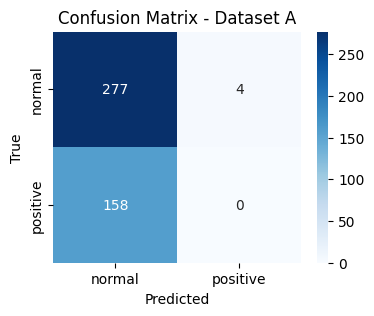

Rapport - miniddsm
              precision    recall  f1-score   support

      normal       0.64      0.99      0.77       281
    positive       0.00      0.00      0.00       158

    accuracy                           0.63       439
   macro avg       0.32      0.49      0.39       439
weighted avg       0.41      0.63      0.50       439



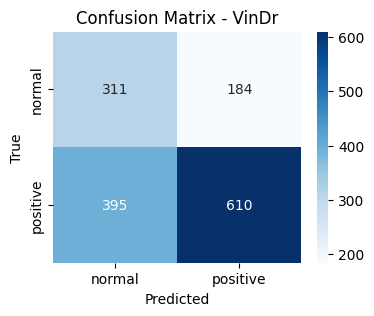

Rapport - VinDr
              precision    recall  f1-score   support

      normal       0.44      0.63      0.52       495
    positive       0.77      0.61      0.68      1005

    accuracy                           0.61      1500
   macro avg       0.60      0.62      0.60      1500
weighted avg       0.66      0.61      0.63      1500



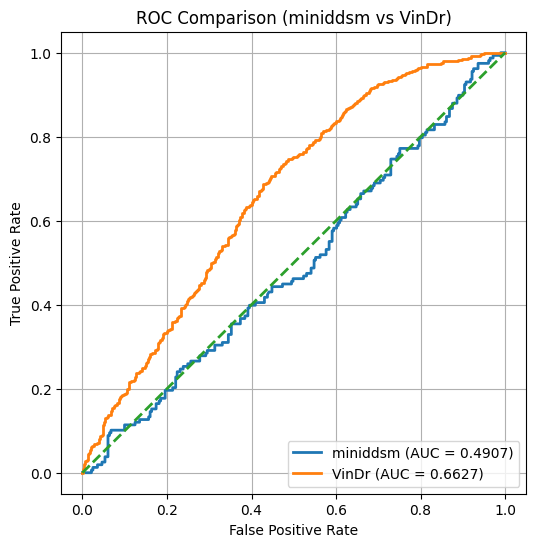

========== Résumé ==========
AUC miniddsm : 0.4907
AUC VinDr : 0.6627
AUC moyenne   : 0.5767


In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# =========================================================
# Paramètres
# =========================================================
class_names = ['normal', 'positive']
model_to_test = model_ewc

# =========================================================
# Fonction pour récupérer preds + probs
# =========================================================
def get_predictions(model, dataloader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())
            all_probabilities.extend(probs[:, 1].cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

# =========================================================
# Dataset A
# =========================================================
labels_A, preds_A, probs_A = get_predictions(model_to_test, val_loader_A, device)

cm_A = confusion_matrix(labels_A, preds_A)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Dataset A")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Rapport - miniddsm")
print(classification_report(labels_A, preds_A, target_names=class_names))

# =========================================================
# Dataset B
# =========================================================
labels_B, preds_B, probs_B = get_predictions(model_to_test, val_loader_B, device)

cm_B = confusion_matrix(labels_B, preds_B)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - VinDr")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Rapport - VinDr")
print(classification_report(labels_B, preds_B, target_names=class_names))

# =========================================================
# ROC curves (COMPARÉES)
# =========================================================
fpr_A, tpr_A, _ = roc_curve(labels_A, probs_A, pos_label=1)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, _ = roc_curve(labels_B, probs_B, pos_label=1)
roc_auc_B = auc(fpr_B, tpr_B)

plt.figure(figsize=(6, 6))

plt.plot(fpr_A, tpr_A, lw=2, label=f'miniddsm (AUC = {roc_auc_A:.4f})')
plt.plot(fpr_B, tpr_B, lw=2, label=f'VinDr (AUC = {roc_auc_B:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison (miniddsm vs VinDr)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# =========================================================
# Résumé
# =========================================================
print("========== Résumé ==========")
print(f"AUC miniddsm : {roc_auc_A:.4f}")
print(f"AUC VinDr : {roc_auc_B:.4f}")
print(f"AUC moyenne   : {(roc_auc_A + roc_auc_B)/2:.4f}")

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model is assumed to be ALREADY trained on dataset A
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("./best_resnet18_model.pth", map_location=device))
model = model.to(device)

model_ewc, history = fine_tune_with_ewc(
    model=model,
    dataloader_A_train=train_loader_A,
    dataloader_B_train=train_loader_B,
    dataloader_A_val=val_loader_A,
    dataloader_B_val=val_loader_B,
    device=device,
    num_epochs=5,
    lr=1e-5,
    lambda_ewc=100000.0,
    fisher_max_batches=100
)

Calcul de la Fisher information...


Fisher: 100%|██████████| 64/64 [02:22<00:00,  2.23s/it, loss=2.34]


Fisher information calculée.
Epoch 1/5 | Train loss: 1.0875 | Val A acc: 0.6059 | Val B acc: 0.5127 | Balanced: 0.5593
Epoch 2/5 | Train loss: 1.0096 | Val A acc: 0.6128 | Val B acc: 0.5600 | Balanced: 0.5864
Epoch 3/5 | Train loss: 0.9792 | Val A acc: 0.6105 | Val B acc: 0.5367 | Balanced: 0.5736
Epoch 4/5 | Train loss: 0.9838 | Val A acc: 0.6059 | Val B acc: 0.5647 | Balanced: 0.5853
Epoch 5/5 | Train loss: 0.9766 | Val A acc: 0.6082 | Val B acc: 0.5413 | Balanced: 0.5748


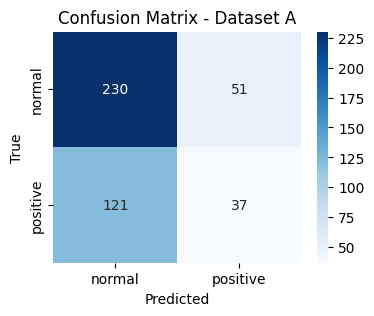

Rapport - miniddsm
              precision    recall  f1-score   support

      normal       0.66      0.82      0.73       281
    positive       0.42      0.23      0.30       158

    accuracy                           0.61       439
   macro avg       0.54      0.53      0.51       439
weighted avg       0.57      0.61      0.57       439



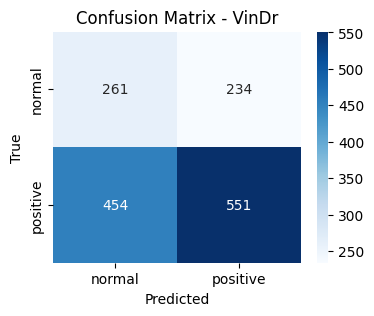

Rapport - VinDr
              precision    recall  f1-score   support

      normal       0.37      0.53      0.43       495
    positive       0.70      0.55      0.62      1005

    accuracy                           0.54      1500
   macro avg       0.53      0.54      0.52      1500
weighted avg       0.59      0.54      0.55      1500



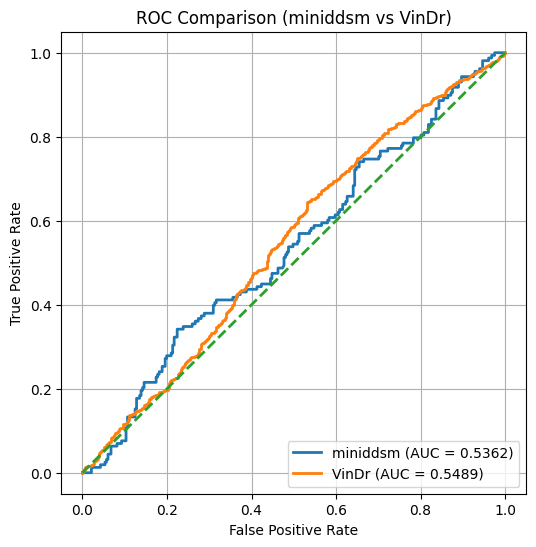

========== Résumé ==========
AUC miniddsm : 0.5362
AUC VinDr : 0.5489
AUC moyenne   : 0.5426


In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# =========================================================
# Paramètres
# =========================================================
class_names = ['normal', 'positive']
model_to_test = model_ewc

# =========================================================
# Fonction pour récupérer preds + probs
# =========================================================
def get_predictions(model, dataloader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())
            all_probabilities.extend(probs[:, 1].cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

# =========================================================
# Dataset A
# =========================================================
labels_A, preds_A, probs_A = get_predictions(model_to_test, val_loader_A, device)

cm_A = confusion_matrix(labels_A, preds_A)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Dataset A")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Rapport - miniddsm")
print(classification_report(labels_A, preds_A, target_names=class_names))

# =========================================================
# Dataset B
# =========================================================
labels_B, preds_B, probs_B = get_predictions(model_to_test, val_loader_B, device)

cm_B = confusion_matrix(labels_B, preds_B)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - VinDr")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Rapport - VinDr")
print(classification_report(labels_B, preds_B, target_names=class_names))

# =========================================================
# ROC curves (COMPARÉES)
# =========================================================
fpr_A, tpr_A, _ = roc_curve(labels_A, probs_A, pos_label=1)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, _ = roc_curve(labels_B, probs_B, pos_label=1)
roc_auc_B = auc(fpr_B, tpr_B)

plt.figure(figsize=(6, 6))

plt.plot(fpr_A, tpr_A, lw=2, label=f'miniddsm (AUC = {roc_auc_A:.4f})')
plt.plot(fpr_B, tpr_B, lw=2, label=f'VinDr (AUC = {roc_auc_B:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison (miniddsm vs VinDr)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# =========================================================
# Résumé
# =========================================================
print("========== Résumé ==========")
print(f"AUC miniddsm : {roc_auc_A:.4f}")
print(f"AUC VinDr : {roc_auc_B:.4f}")
print(f"AUC moyenne   : {(roc_auc_A + roc_auc_B)/2:.4f}")

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

def test(valeur_lambda, nb_epochs):
    # model is assumed to be ALREADY trained on dataset A
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = models.resnet18()
    model.fc = torch.nn.Linear(model.fc.in_features, 2)
    model.load_state_dict(torch.load("./best_resnet18_model.pth", map_location=device))
    model = model.to(device)
    
    model_ewc, history = fine_tune_with_ewc(
        model=model,
        dataloader_A_train=train_loader_A,
        dataloader_B_train=train_loader_B,
        dataloader_A_val=val_loader_A,
        dataloader_B_val=val_loader_B,
        device=device,
        num_epochs=nb_epochs,
        lr=1e-5,
        lambda_ewc=valeur_lambda,
        fisher_max_batches=100
    )

    # =========================================================
    # Paramètres
    # =========================================================
    class_names = ['normal', 'positive']
    model_to_test = model_ewc
    
    # =========================================================
    # Fonction pour récupérer preds + probs
    # =========================================================
    def get_predictions(model, dataloader, device):
        model.eval()
    
        all_labels = []
        all_predictions = []
        all_probabilities = []
    
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(outputs, dim=1)
    
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(preds.cpu().numpy())
                all_probabilities.extend(probs[:, 1].cpu().numpy())
    
        return (
            np.array(all_labels),
            np.array(all_predictions),
            np.array(all_probabilities)
        )
    
    # =========================================================
    # Dataset A
    # =========================================================
    labels_A, preds_A, probs_A = get_predictions(model_to_test, val_loader_A, device)
    
    cm_A = confusion_matrix(labels_A, preds_A)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix - Dataset A")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    
    print("Rapport - miniddsm")
    print(classification_report(labels_A, preds_A, target_names=class_names))
    
    # =========================================================
    # Dataset B
    # =========================================================
    labels_B, preds_B, probs_B = get_predictions(model_to_test, val_loader_B, device)
    
    cm_B = confusion_matrix(labels_B, preds_B)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_B, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix - VinDr")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    
    print("Rapport - VinDr")
    print(classification_report(labels_B, preds_B, target_names=class_names))
    
    # =========================================================
    # ROC curves (COMPARÉES)
    # =========================================================
    fpr_A, tpr_A, _ = roc_curve(labels_A, probs_A, pos_label=1)
    roc_auc_A = auc(fpr_A, tpr_A)
    
    fpr_B, tpr_B, _ = roc_curve(labels_B, probs_B, pos_label=1)
    roc_auc_B = auc(fpr_B, tpr_B)
    
    plt.figure(figsize=(6, 6))
    
    plt.plot(fpr_A, tpr_A, lw=2, label=f'miniddsm (AUC = {roc_auc_A:.4f})')
    plt.plot(fpr_B, tpr_B, lw=2, label=f'VinDr (AUC = {roc_auc_B:.4f})')
    
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2)
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Comparison (miniddsm vs VinDr)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    
    # =========================================================
    # Résumé
    # =========================================================
    print("========== Résumé ==========")
    print(f"AUC miniddsm : {roc_auc_A:.4f}")
    print(f"AUC VinDr : {roc_auc_B:.4f}")
    print(f"AUC moyenne   : {(roc_auc_A + roc_auc_B)/2:.4f}")
        
    
        

Calcul de la Fisher information...


Fisher: 100%|██████████| 64/64 [02:14<00:00,  2.10s/it, loss=2.66]


Fisher information calculée.
Epoch 1/10 | Train loss: 1.0081 | Val A acc: 0.6128 | Val B acc: 0.5493 | Balanced: 0.5810
Epoch 2/10 | Train loss: 0.9522 | Val A acc: 0.6196 | Val B acc: 0.5427 | Balanced: 0.5811
Epoch 3/10 | Train loss: 0.9456 | Val A acc: 0.6128 | Val B acc: 0.5687 | Balanced: 0.5907
Epoch 4/10 | Train loss: 0.9346 | Val A acc: 0.6128 | Val B acc: 0.5540 | Balanced: 0.5834
Epoch 5/10 | Train loss: 0.9200 | Val A acc: 0.6264 | Val B acc: 0.5767 | Balanced: 0.6015
Epoch 6/10 | Train loss: 0.8900 | Val A acc: 0.6150 | Val B acc: 0.5620 | Balanced: 0.5885
Epoch 7/10 | Train loss: 0.9059 | Val A acc: 0.6219 | Val B acc: 0.5140 | Balanced: 0.5679
Epoch 8/10 | Train loss: 0.9093 | Val A acc: 0.6150 | Val B acc: 0.5553 | Balanced: 0.5852
Epoch 9/10 | Train loss: 0.8716 | Val A acc: 0.6105 | Val B acc: 0.5273 | Balanced: 0.5689
Epoch 10/10 | Train loss: 0.8814 | Val A acc: 0.6150 | Val B acc: 0.5313 | Balanced: 0.5732


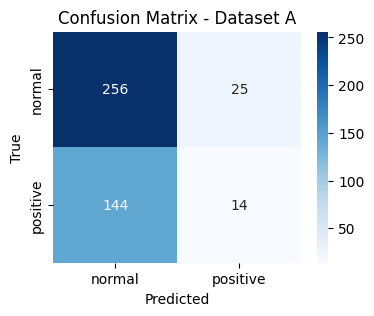

Rapport - miniddsm
              precision    recall  f1-score   support

      normal       0.64      0.91      0.75       281
    positive       0.36      0.09      0.14       158

    accuracy                           0.62       439
   macro avg       0.50      0.50      0.45       439
weighted avg       0.54      0.62      0.53       439



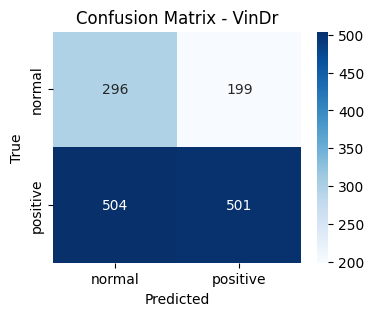

Rapport - VinDr
              precision    recall  f1-score   support

      normal       0.37      0.60      0.46       495
    positive       0.72      0.50      0.59      1005

    accuracy                           0.53      1500
   macro avg       0.54      0.55      0.52      1500
weighted avg       0.60      0.53      0.54      1500



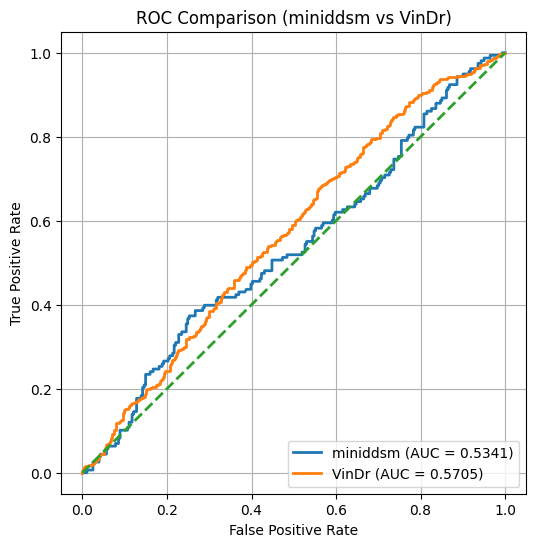

========== Résumé ==========
AUC miniddsm : 0.5341
AUC VinDr : 0.5705
AUC moyenne   : 0.5523


In [12]:
test(50000, 10)